<a href="https://colab.research.google.com/github/sheershaagrawal/projectdatamites/blob/master/Pneumonia_Detection_Using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BUSINESS CASE

Pneumonia is a serious lung infection that requires early detection.
Manual diagnosis using X-rays is time-consuming and error-prone.

👉 This project builds a deep learning model to automatically detect pneumonia.

PROJECT GOAL

1. Perform image preprocessing
2. Build CNN model to classify X-rays
3. Predict Pneumonia vs Normal

DATASET UNDERSTANDING

Dataset contains:

NORMAL → Healthy patients
PNEUMONIA → Infected patients

👉 Binary classification problem

IMPORT LIBRARIES

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

CONNECT GOOGLE DRIVE

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


UNZIP DATASET

In [3]:
import zipfile

zip_path = '/content/drive/MyDrive/Chest-Xray-2.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/xray_data')

print("Dataset Ready")

Dataset Ready


In [5]:
import os

for root, dirs, files in os.walk('/content/xray_data'):
    print(root)

/content/xray_data
/content/xray_data/chest_xray
/content/xray_data/chest_xray/train
/content/xray_data/chest_xray/train/NORMAL
/content/xray_data/chest_xray/train/PNEUMONIA
/content/xray_data/chest_xray/test
/content/xray_data/chest_xray/test/NORMAL
/content/xray_data/chest_xray/test/PNEUMONIA
/content/xray_data/chest_xray/val
/content/xray_data/chest_xray/val/NORMAL
/content/xray_data/chest_xray/val/PNEUMONIA


IMAGE PREPROCESSING

In [6]:
import os
import cv2
import numpy as np

data = []
labels = []

categories = ['NORMAL', 'PNEUMONIA']
path = '/content/xray_data/chest_xray/train'

for category in categories:
    folder = os.path.join(path, category)
    label = categories.index(category)

    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)

        try:
            image = cv2.imread(img_path)
            image = cv2.resize(image, (150,150))

            data.append(image)
            labels.append(label)
        except:
            pass

data = np.array(data)
labels = np.array(labels)

print("Data Loaded:", data.shape)
print("Classes:", categories)

Data Loaded: (5216, 150, 150, 3)
Classes: ['NORMAL', 'PNEUMONIA']


NORMALIZATION

In [7]:
data = data / 255.0

TRAIN-TEST SPLIT

In [8]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2)

CNN MODEL

In [9]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,563,713 (36.48 MB)

 Trainable params: 9,563,713 (36.48 MB)

 Non-trainable params: 0 (0.00 B)

TRAIN MODEL

In [10]:
history = model.fit(X_train, y_train,
                    epochs=10,
                    validation_data=(X_test, y_test))

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.8698 - loss: 0.3475 - val_accuracy: 0.9540 - val_loss: 0.1291
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - accuracy: 0.9511 - loss: 0.1286 - val_accuracy: 0.9521 - val_loss: 0.1142
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 249s 2s/step - accuracy: 0.9607 - loss: 0.1044 - val_accuracy: 0.9521 - val_loss: 0.1588
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 242s 2s/step - accuracy: 0.9703 - loss: 0.0826 - val_accuracy: 0.9511 - val_loss: 0.1251
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - accuracy: 0.9729 - loss: 0.0733 - val_accuracy: 0.9761 - val_loss: 0.0705
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 242s 2s/step - accuracy: 0.9787 - loss: 0.0582 - val_accuracy: 0.9703 - val_loss: 0.0758
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - accuracy: 0.9820 - loss: 0.0505 - val_accuracy: 0.9713 - val_loss: 0.0730
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.9871 - loss: 0.0381 - val_accu

EVALUATION

In [11]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 637ms/step - accuracy: 0.9761 - loss: 0.1128
Test Accuracy: 0.9760536551475525


VISUALIZATION

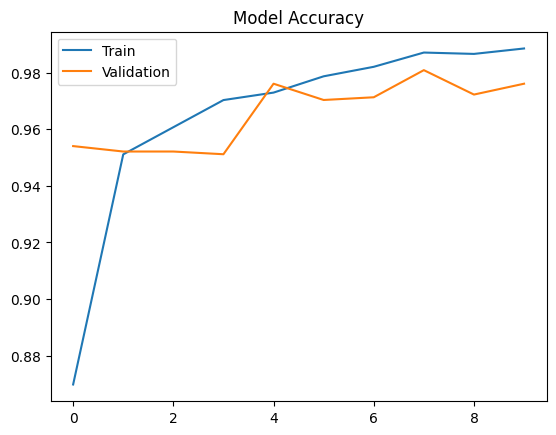

In [12]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Model Accuracy")
plt.show()

PREDICTION

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 678ms/step
Prediction: PNEUMONIA


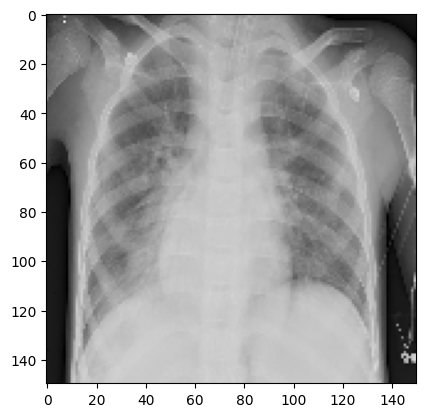

In [13]:
img = X_test[0]
plt.imshow(img)

pred = model.predict(np.expand_dims(img, axis=0))
print("Prediction:", "PNEUMONIA" if pred > 0.5 else "NORMAL")

CONCLUSION
1. CNN model successfully classified chest X-ray images
2. Achieved good accuracy
3. Useful for early pneumonia detection
Can assist doctors in diagnosis

FUTURE SCOPE
1. Use Transfer Learning (ResNet, VGG16)
2. Deploy model as web application
3. Improve accuracy using data augmentation